SCENARIO 1 – SVD(24BAD076)

Index(['userId', 'movieId', 'rating', 'timestamp'], dtype='object')
RMSE: 0.35559073193490726
MAE: 0.10059487772181518


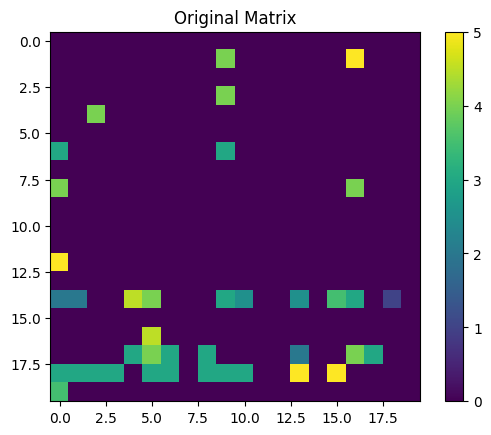

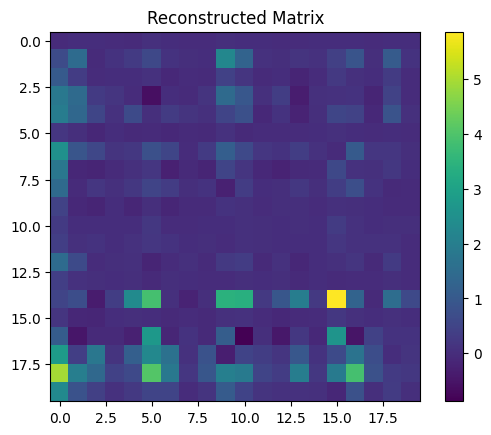

Top Recommendations (Movie IDs): [2380 1125 1036 1114  970]


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import mean_squared_error, mean_absolute_error
from numpy.linalg import svd

df = pd.read_csv('ratings.csv')

print(df.columns)

df = df[['userId','movieId','rating']]

user_item = df.pivot(index='userId', columns='movieId', values='rating')

user_item_filled = user_item.fillna(0)

mean = np.mean(user_item_filled, axis=1)
user_item_centered = user_item_filled.sub(mean, axis=0)

U, S, Vt = svd(user_item_centered, full_matrices=False)

k = 20
U_k = U[:, :k]
S_k = np.diag(S[:k])
Vt_k = Vt[:k, :]

reconstructed = np.dot(np.dot(U_k, S_k), Vt_k) + mean.values.reshape(-1,1)

rmse = np.sqrt(mean_squared_error(user_item_filled.values, reconstructed))
mae = mean_absolute_error(user_item_filled.values, reconstructed)

print("RMSE:", rmse)
print("MAE:", mae)

plt.figure()
plt.imshow(user_item_filled.values[:20, :20])
plt.title("Original Matrix")
plt.colorbar()
plt.show()

plt.figure()
plt.imshow(reconstructed[:20, :20])
plt.title("Reconstructed Matrix")
plt.colorbar()
plt.show()

user_id = 1
user_row = reconstructed[user_id-1]

top_movies = np.argsort(user_row)[-5:]

print("Top Recommendations (Movie IDs):", top_movies)

SCENARIO 2 – NMF(24BAD076)

/usr/local/lib/python3.12/dist-packages/sklearn/decomposition/_nmf.py:1742: ConvergenceWarning: Maximum number of iterations 200 reached. Increase it to improve convergence.
  warnings.warn(


RMSE: 0.36418755287188476


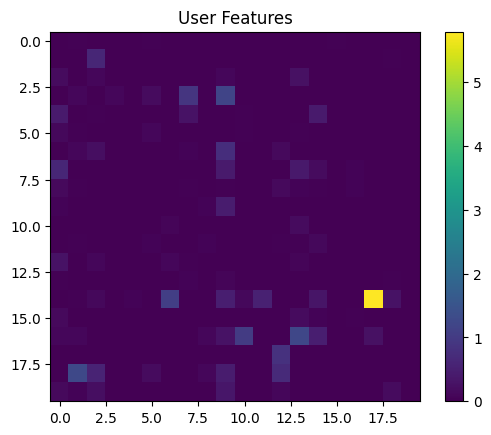

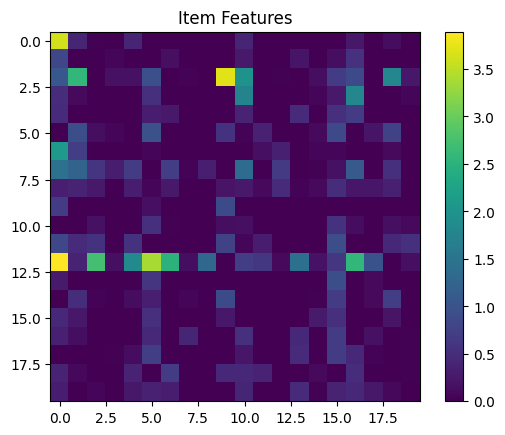

Top Recommendations (Movie IDs): [1728  912  951 1006  870]


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.decomposition import NMF
from sklearn.metrics import mean_squared_error

df = pd.read_csv('ratings.csv')

df = df[['userId','movieId','rating']]

user_item = df.pivot(index='userId', columns='movieId', values='rating')

user_item_filled = user_item.fillna(0)

nmf = NMF(n_components=20, random_state=42)

W = nmf.fit_transform(user_item_filled)
H = nmf.components_

reconstructed = np.dot(W, H)

rmse = np.sqrt(mean_squared_error(user_item_filled, reconstructed))
print("RMSE:", rmse)

plt.figure()
plt.imshow(W[:20,:20])
plt.title("User Features")
plt.colorbar()
plt.show()

plt.figure()
plt.imshow(H[:20,:20])
plt.title("Item Features")
plt.colorbar()
plt.show()

user_id = 1
user_row = reconstructed[user_id-1]

top_movies = np.argsort(user_row)[-5:]

print("Top Recommendations (Movie IDs):", top_movies)